<a href="https://www.kaggle.com/code/lalit7881/gold-price-history-1833-2026-eda?scriptVersionId=315471290" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/uzmaakhtar/gold-price-history-18332026/monthly.csv
/kaggle/input/datasets/uzmaakhtar/gold-price-history-18332026/gold_advanced_features.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/uzmaakhtar/gold-price-history-18332026/monthly.csv")

In [3]:
df.head()

,Date,Price
0,1833-01,18.93
1,1833-02,18.93
2,1833-03,18.93
3,1833-04,18.93
4,1833-05,18.93


In [4]:
df.tail()

,Date,Price
2313,2025-10,4058.33
2314,2025-11,4087.19
2315,2025-12,4309.23
2316,2026-01,4752.75
2317,2026-02,5019.97


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2318 entries, 0 to 2317
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2318 non-null   object 
 1   Price   2318 non-null   float64
dtypes: float64(1), object(1)
memory usage: 36.3+ KB


In [6]:
df.describe()

,Price
count,2318.000000
mean,232.232352
std,508.694544
min,17.060000
25%,18.940000
50%,20.680000
75%,176.300000
max,5019.970000


In [7]:
df.isnull().sum()

Date     0
Price    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Date      object
Price    float64
dtype: object

In [10]:
df.shape

(2318, 2)

In [11]:
df.columns

Index(['Date', 'Price'], dtype='object')

In [12]:
df.nunique()

Date     2318
Price     734
dtype: int64

## EDA

In [13]:

from statsmodels.tsa.seasonal import seasonal_decompose

# Style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)


# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Sort values
df = df.sort_values('Date')

# Set Date as index (important for time series)
df.set_index('Date', inplace=True)

print(df.head())

            Price
Date             
1833-01-01  18.93
1833-02-01  18.93
1833-03-01  18.93
1833-04-01  18.93
1833-05-01  18.93


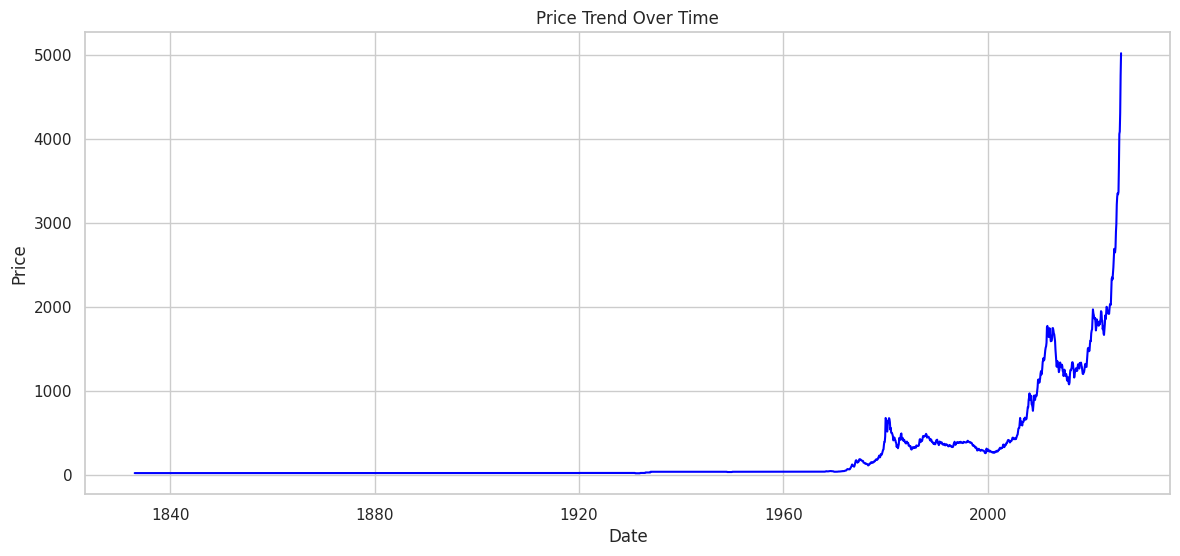

In [14]:
plt.figure()
plt.plot(df.index, df['Price'], color='blue')
plt.title("Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

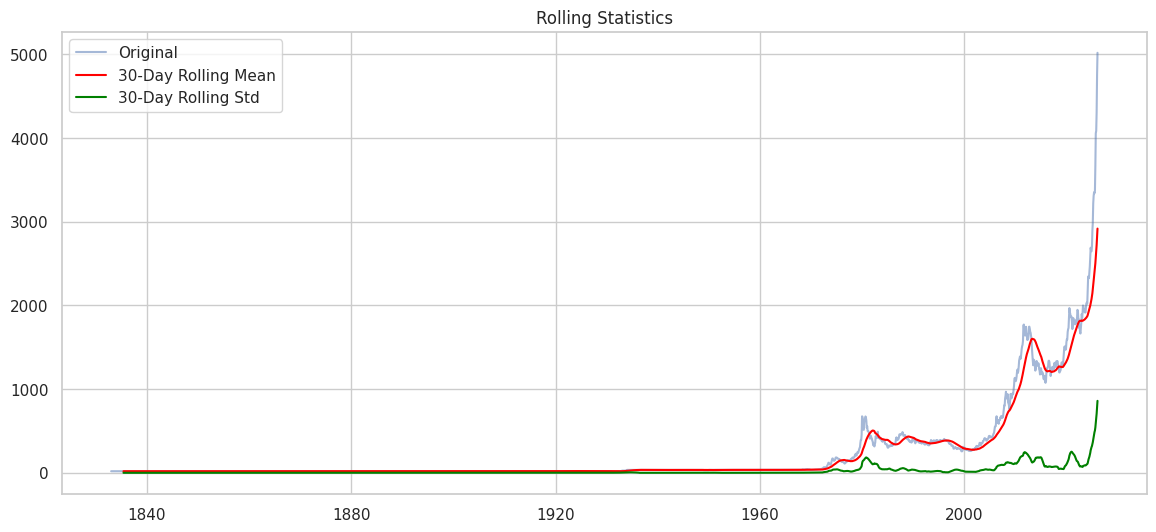

In [15]:
df['Rolling_Mean_30'] = df['Price'].rolling(window=30).mean()
df['Rolling_Std_30'] = df['Price'].rolling(window=30).std()

plt.figure()
plt.plot(df['Price'], label='Original', alpha=0.5)
plt.plot(df['Rolling_Mean_30'], label='30-Day Rolling Mean', color='red')
plt.plot(df['Rolling_Std_30'], label='30-Day Rolling Std', color='green')

plt.title("Rolling Statistics")
plt.legend()
plt.show()

In [16]:
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day'] = df.index.day
df['DayOfWeek'] = df.index.dayofweek

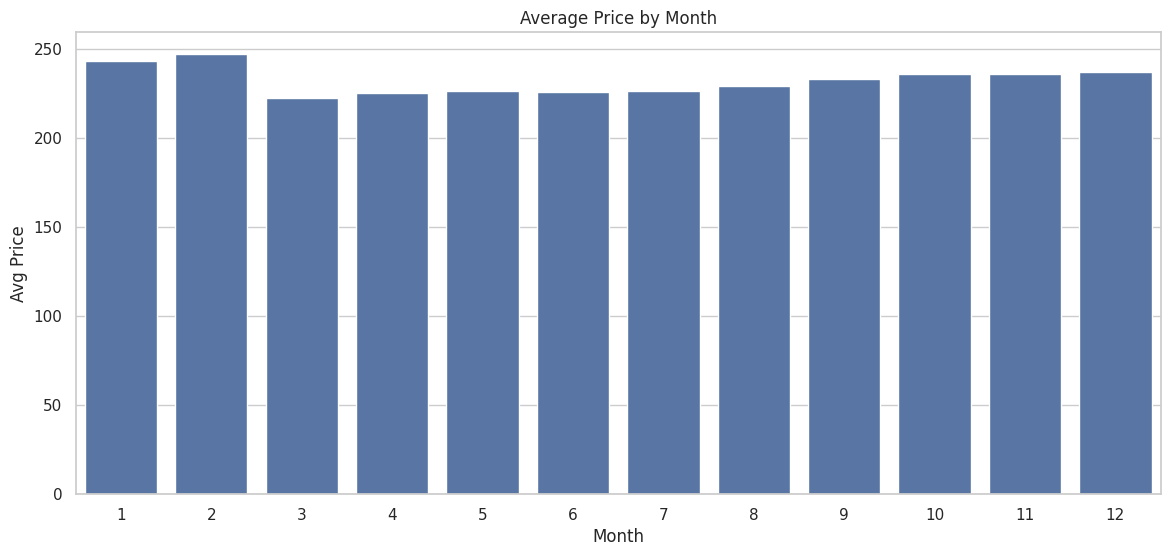

In [17]:
monthly_avg = df.groupby('Month')['Price'].mean()

plt.figure()
sns.barplot(x=monthly_avg.index, y=monthly_avg.values)

plt.title("Average Price by Month")
plt.xlabel("Month")
plt.ylabel("Avg Price")
plt.show()

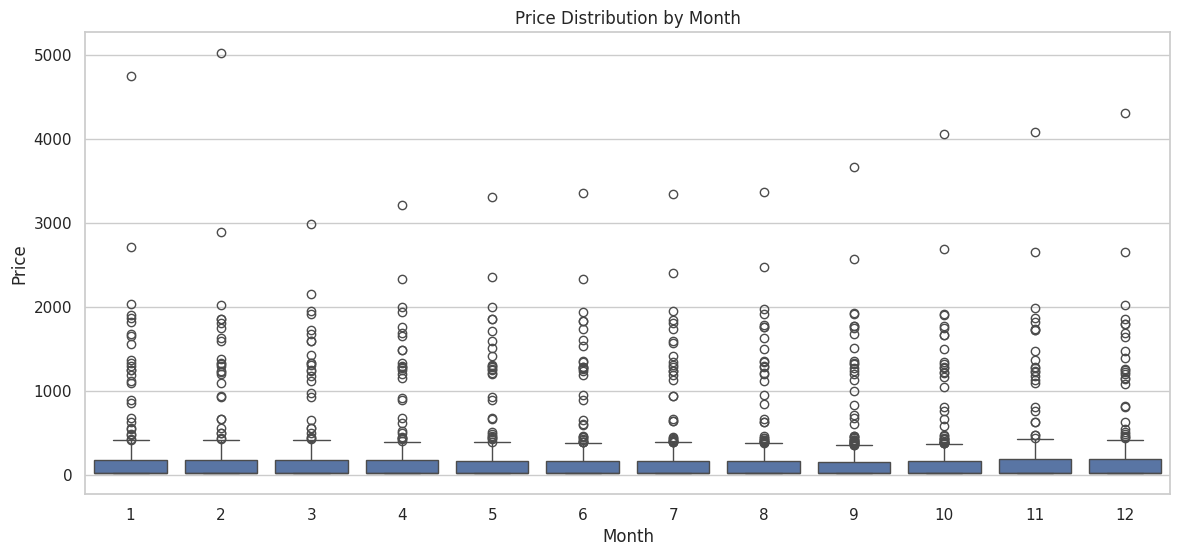

In [18]:
plt.figure()
sns.boxplot(x='Month', y='Price', data=df.reset_index())

plt.title("Price Distribution by Month")
plt.show()

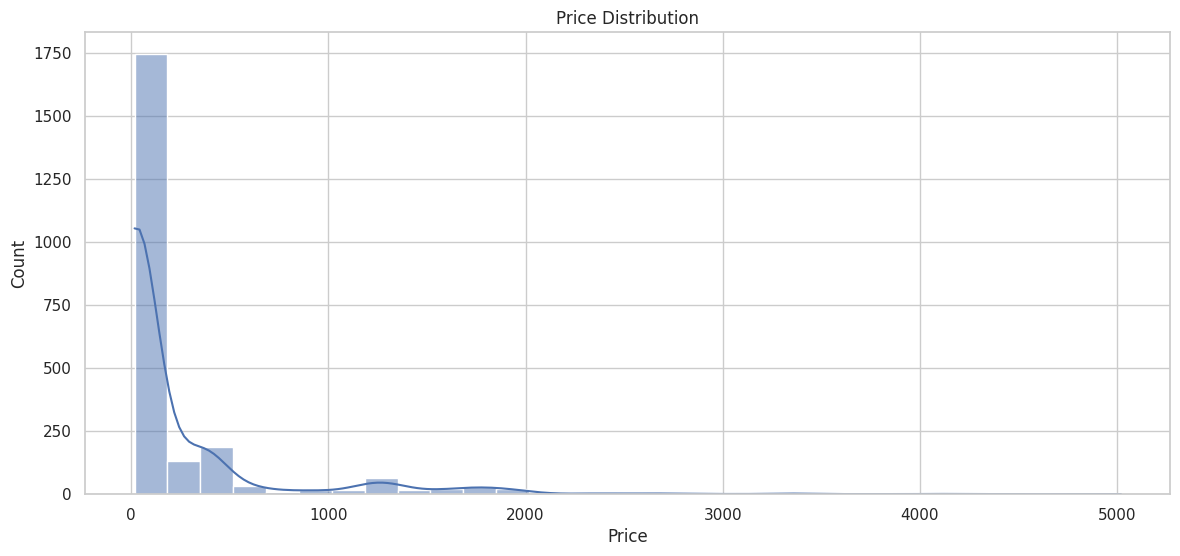

In [19]:
plt.figure()
sns.histplot(df['Price'], bins=30, kde=True)

plt.title("Price Distribution")
plt.show()

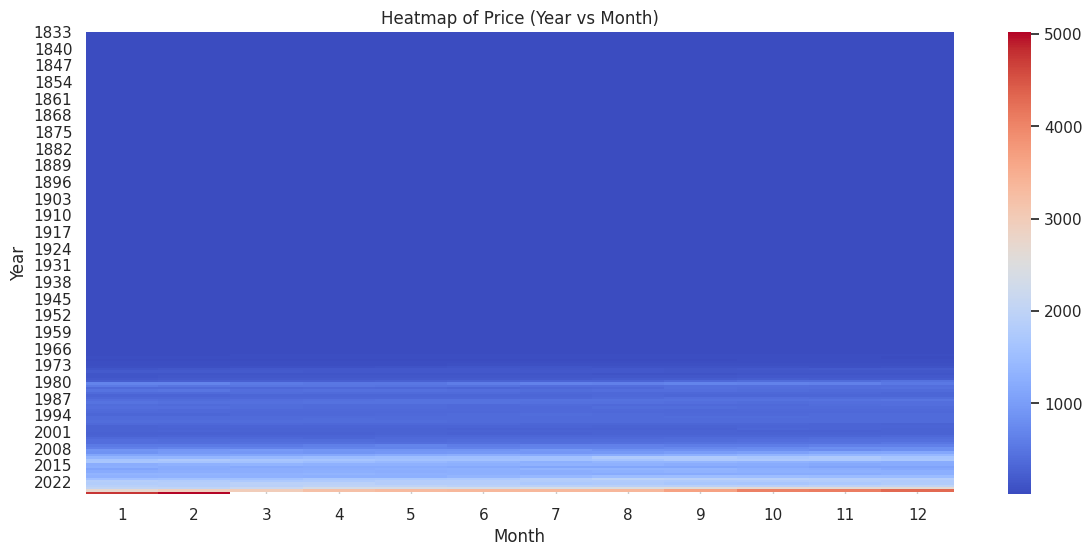

In [20]:
pivot = df.pivot_table(values='Price', index='Year', columns='Month')

plt.figure()
sns.heatmap(pivot, cmap='coolwarm', annot=False)

plt.title("Heatmap of Price (Year vs Month)")
plt.show()

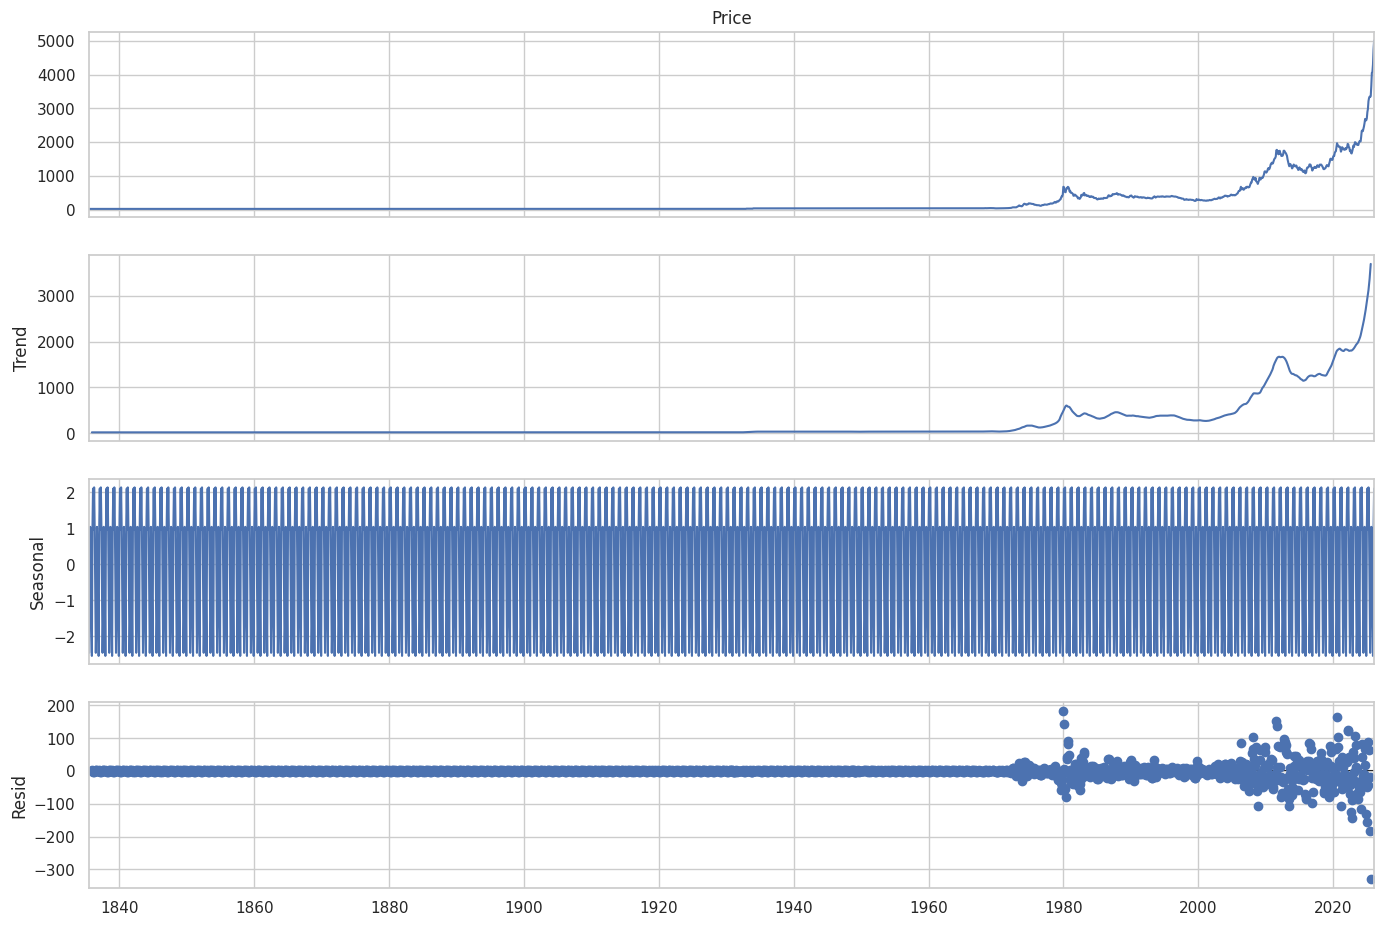

In [21]:
# Ensure no missing values
df = df.dropna()

decomposition = seasonal_decompose(df['Price'], model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

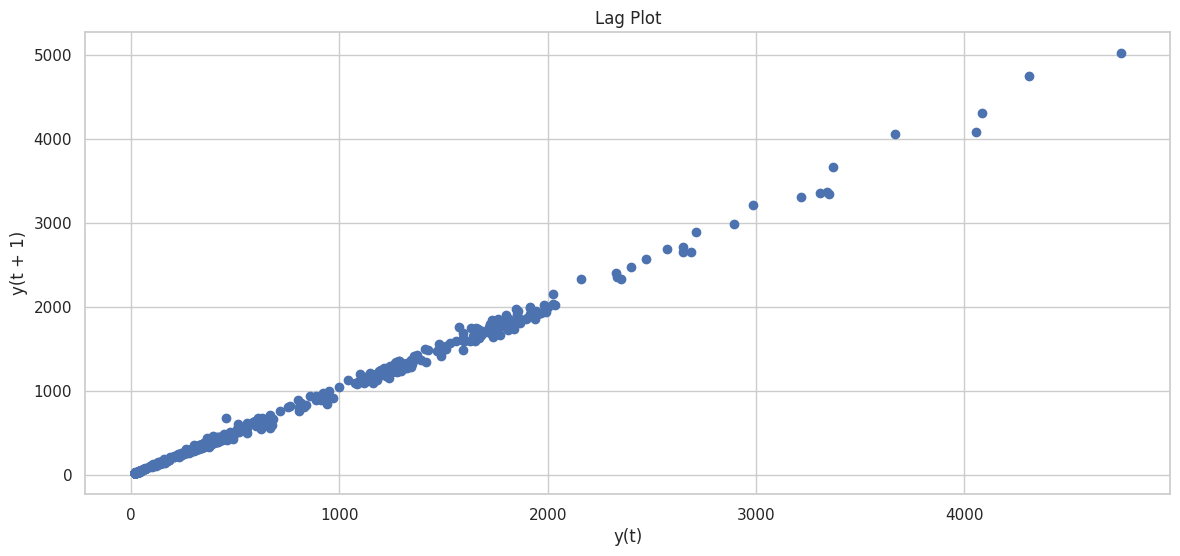

In [22]:
from pandas.plotting import lag_plot

plt.figure()
lag_plot(df['Price'])
plt.title("Lag Plot")
plt.show()

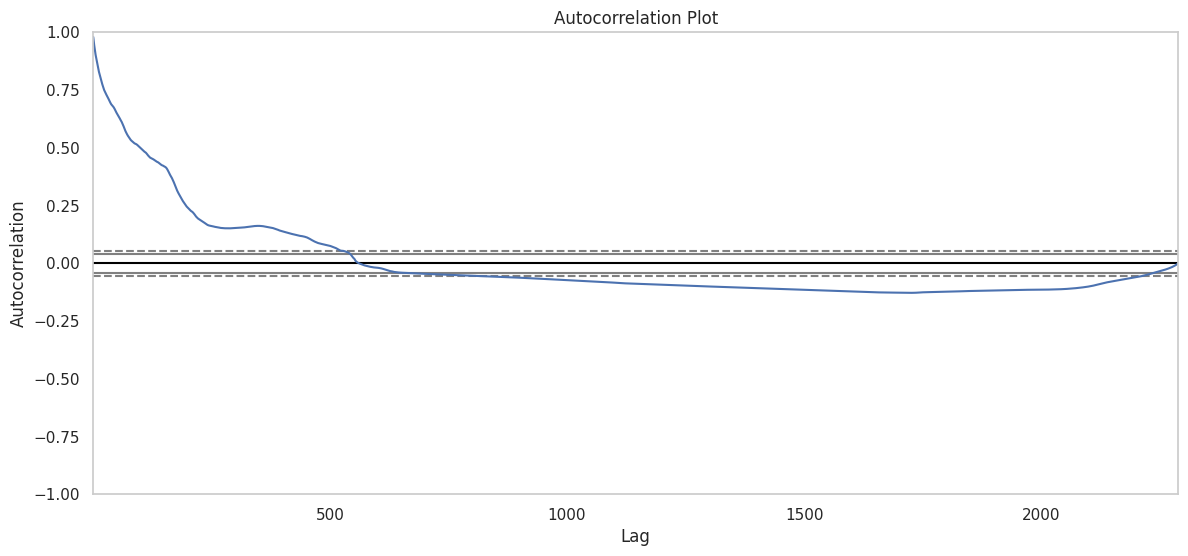

In [23]:
from pandas.plotting import autocorrelation_plot

plt.figure()
autocorrelation_plot(df['Price'])
plt.title("Autocorrelation Plot")
plt.show()

In [24]:
print(df.columns)

Index(['Price', 'Rolling_Mean_30', 'Rolling_Std_30', 'Year', 'Month', 'Day',
       'DayOfWeek'],
      dtype='object')


## Feature engineering

Logistic Regression Accuracy: 0.5131004366812227
Random Forest Accuracy: 0.4432314410480349


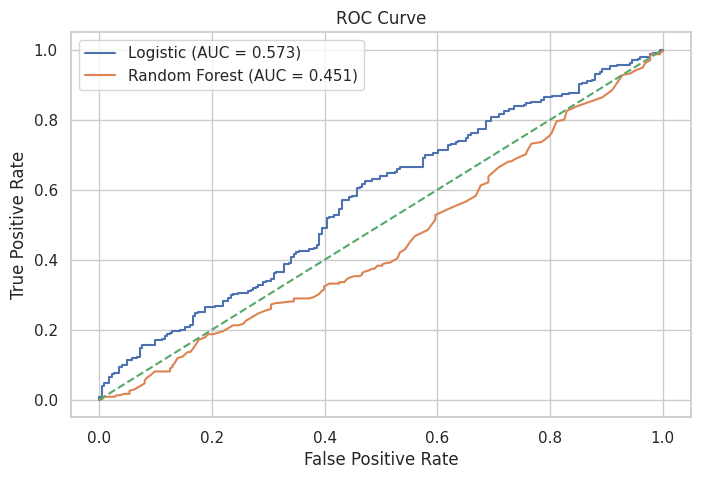

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# =========================================
# 3. CREATE TARGET (NO LEAKAGE)
# =========================================
df['target'] = (df['Price'].shift(-1) > df['Price']).astype(int)

# =========================================
# 4. ADD LAG FEATURES (IMPORTANT)
# =========================================
df['lag_1'] = df['Price'].shift(1)
df['lag_2'] = df['Price'].shift(2)

# Drop NaN values after feature creation
df = df.dropna()

# =========================================
# 5. SELECT FEATURES
# =========================================
features = [
    'Rolling_Mean_30',
    'Rolling_Std_30',
    'Year',
    'Month',
    'Day',
    'DayOfWeek',
    'lag_1',
    'lag_2'
]

X = df[features]
y = df['target']

# =========================================
# 6. TRAIN-TEST SPLIT (TIME SERIES SAFE)
# =========================================
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# =========================================
# 7. SCALING (ONLY FOR LOGISTIC)
# =========================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================
# 8. TRAIN MODELS
# =========================================
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# =========================================
# 9. PREDICTIONS
# =========================================
# Logistic
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Random Forest
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# =========================================
# 10. ACCURACY
# =========================================
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# =========================================
# 11. ROC CURVE
# =========================================
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Plot ROC Curve
plt.figure(figsize=(8,5))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic (AUC = {auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## Thank you...pls upvote!!!!!!!!!